<h3>Bookstore Sales Analysis</h3>

<b>1. Import Libraries</b>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

<b>2. Data Reading</b>

In [4]:
# Read the Bookstore Sales Dataset
data = pd.read_csv("bookstore_sales.csv")

# Display the first 5 rows of the dataset
print("First 5 rows of the dataset:")
print(data.head())

First 5 rows of the dataset:
               BookTitle      Genre  Sales   OrderDate   PaymentMethod  \
0                Sapiens   Classics   5.16  2024-01-01     Credit Card   
1                Sapiens    Fantasy  99.75  2024-01-01  Digital Wallet   
2  To Kill a Mockingbird  Biography  15.89  2024-01-01     Credit Card   
3           Harry Potter  Biography  46.48  2024-01-01            Cash   
4                Sapiens    Fiction  82.63  2024-01-01  Digital Wallet   

      Location  
0  Los Angeles  
1      Chicago  
2     New York  
3     New York  
4      Chicago  


<b>3. Data Cleaning</b>

In [5]:
# Check for missing values
print("\nMissing Values:")
print(data.isnull().sum())

# Fill missing values (if any) with 0
data.fillna(0, inplace=True)

# Remove duplicate rows
data.drop_duplicates(inplace=True)

# Ensure date columns are in datetime format
data['OrderDate'] = pd.to_datetime(data['OrderDate'])

# Display dataset information
print("\nDataset Information:")
print(data.info())

# Descriptive statistics
print("\nDescriptive Statistics:")
print(data.describe())


Missing Values:
BookTitle        0
Genre            0
Sales            0
OrderDate        0
PaymentMethod    0
Location         0
dtype: int64

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   BookTitle      1000 non-null   object        
 1   Genre          1000 non-null   object        
 2   Sales          1000 non-null   float64       
 3   OrderDate      1000 non-null   datetime64[ns]
 4   PaymentMethod  1000 non-null   object        
 5   Location       1000 non-null   object        
dtypes: datetime64[ns](1), float64(1), object(4)
memory usage: 31.3+ KB
None

Descriptive Statistics:
             Sales                   OrderDate
count  1000.000000                        1000
mean     53.718930  2024-01-21 08:03:50.400000
min       5.030000         2024-01-01 00:00:00
25%      29.787500         2024

<b>4. Visualization<b>
<p>1. Total Sales by Genre</p>

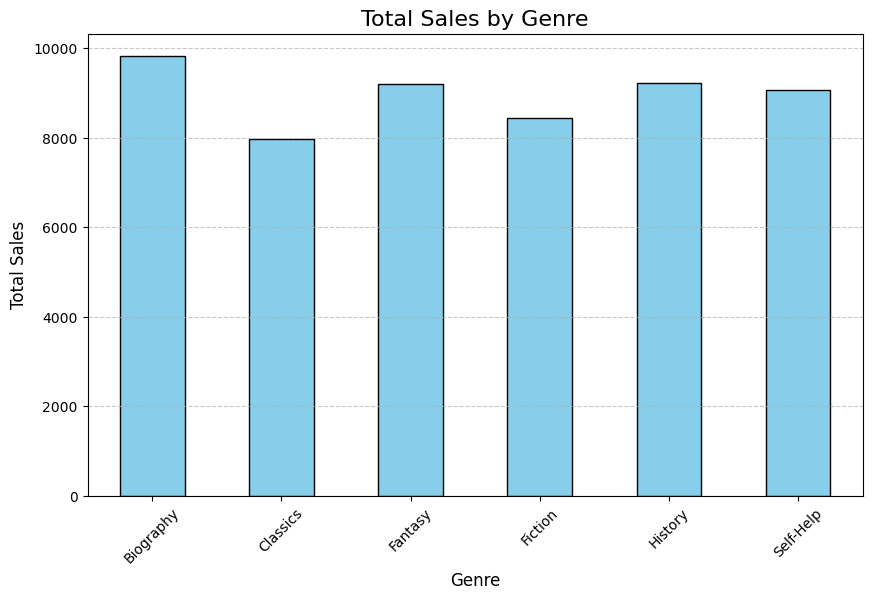

In [6]:
# Group sales by genre
genre_sales = data.groupby('Genre')['Sales'].sum()

# Bar chart for Total Sales by Genre
plt.figure(figsize=(10, 6))
genre_sales.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Total Sales by Genre', fontsize=16)
plt.xlabel('Genre', fontsize=12)
plt.ylabel('Total Sales', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

<p>2. Monthly Sales Trend</p>

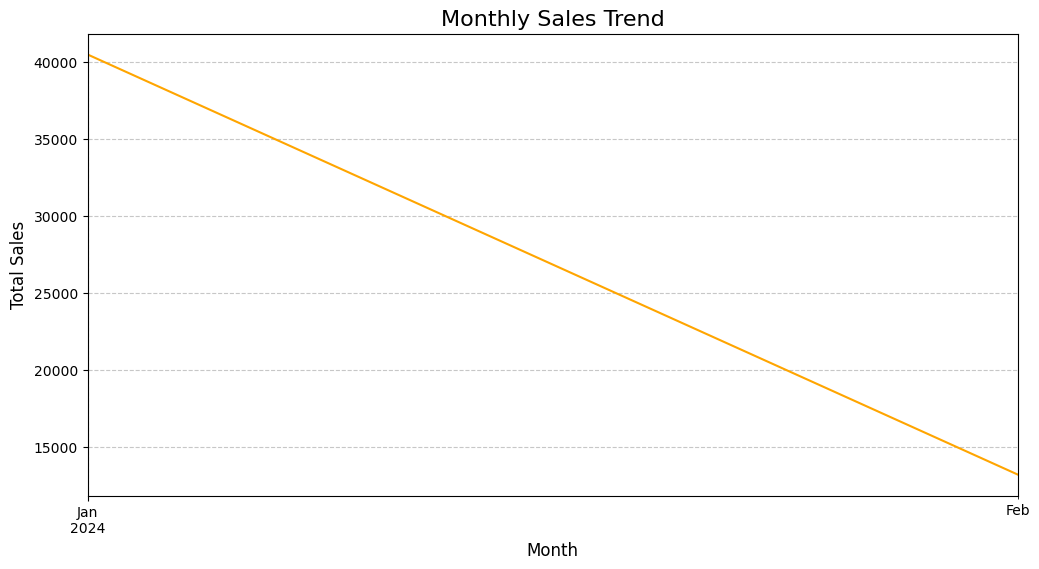

In [7]:
# Extract year and month from OrderDate
data['YearMonth'] = data['OrderDate'].dt.to_period('M')

# Group sales by year and month
monthly_sales = data.groupby('YearMonth')['Sales'].sum()

# Line chart for Monthly Sales Trend
plt.figure(figsize=(12, 6))
monthly_sales.plot(kind='line', color='orange')
plt.title('Monthly Sales Trend', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Sales', fontsize=12)
plt.grid(axis='both', linestyle='--', alpha=0.7)
plt.show()

<p>3. Top 10 Best-Selling Books</p>

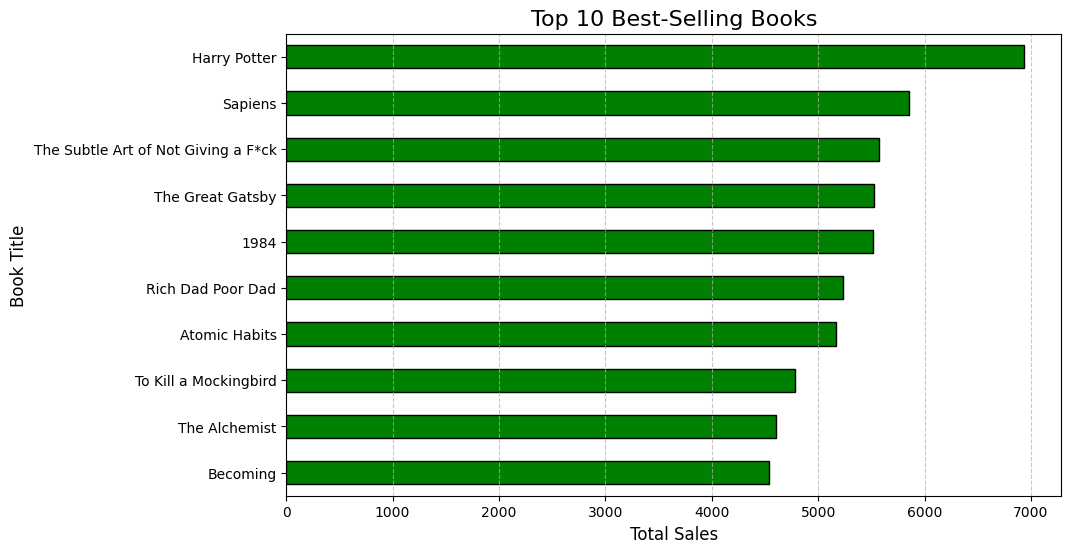

In [8]:
# Top 10 best-selling books by sales
top_books = data.groupby('BookTitle')['Sales'].sum().sort_values(ascending=False).head(10)

# Horizontal bar chart for Top 10 Best-Selling Books
plt.figure(figsize=(10, 6))
top_books.plot(kind='barh', color='green', edgecolor='black')
plt.title('Top 10 Best-Selling Books', fontsize=16)
plt.xlabel('Total Sales', fontsize=12)
plt.ylabel('Book Title', fontsize=12)
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

<p>4. Sales Contribution by Payment Method</p>

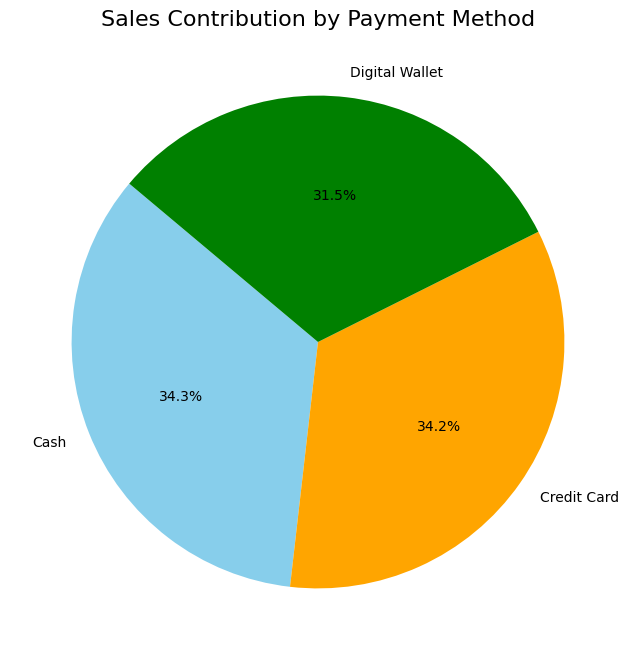

In [9]:
# Pie chart for sales by payment method
payment_sales = data.groupby('PaymentMethod')['Sales'].sum()

plt.figure(figsize=(8, 8))
payment_sales.plot(kind='pie', autopct='%1.1f%%', startangle=140, colors=['skyblue', 'orange', 'green'])
plt.title('Sales Contribution by Payment Method', fontsize=16)
plt.ylabel('')  # Hide y-axis label
plt.show()

<p>5: Sales Distribution by Customer Location</p>

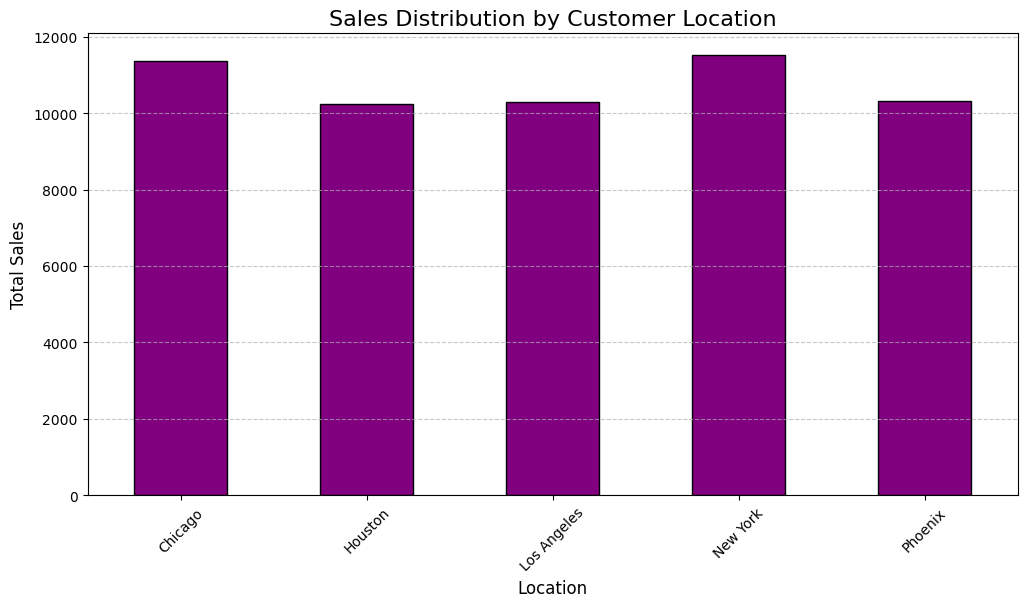

In [10]:
# Bar chart for sales by location
location_sales = data.groupby('Location')['Sales'].sum()

plt.figure(figsize=(12, 6))
location_sales.plot(kind='bar', color='purple', edgecolor='black')
plt.title('Sales Distribution by Customer Location', fontsize=16)
plt.xlabel('Location', fontsize=12)
plt.ylabel('Total Sales', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

<b>5. Conclusion</b>
<p>The analysis of bookstore sales data provides valuable insights into the performance of different genres, books, and customer behaviors. It was observed that certain genres, like fiction and self-help, generated the highest sales, indicating their popularity. Monthly sales trends revealed a seasonal pattern, with higher sales during certain months, possibly due to holidays or promotional events. The top 10 best-selling books demonstrated the impact of popular titles on total revenue, suggesting the importance of stocking bestsellers. Additionally, payment methods showed varying contributions, with card payments being the most preferred. Finally, customer location analysis highlighted key areas contributing to sales, which could help target marketing efforts. These insights can assist the bookstore in optimizing inventory, marketing strategies, and customer engagement to boost sales.</p>